# Trader Performance vs Market Sentiment Analysis

This notebook analyzes the relationship between Bitcoin market sentiment 
(Fear vs Greed) and trader behavior on Hyperliquid.

The goal is to identify patterns in trading performance and behavior 
that could inform better trading strategies.

Datasets Used:
1. Bitcoin Market Sentiment (Fear/Greed)
2. Hyperliquid Historical Trader Data

## Import Required Libraries

We import libraries used for:

- Data manipulation (pandas, numpy)
- Data visualization (matplotlib, seaborn)
- Data analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load the Datasets

We load the two datasets used in this analysis:

1. Fear/Greed sentiment dataset
2. Hyperliquid trader transaction dataset

In [19]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("compressed_data.csv.gz")

print("Sentiment Dataset Shape:", sentiment.shape)
print("Trades Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


## Missing Values Check

Missing values can impact analysis results. 
We check both datasets for null values.

In [20]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [21]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

## Duplicate Records

Duplicate rows can distort analysis results. 
We remove duplicate entries from both datasets.

In [22]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

## Timestamp Conversion

The trader dataset contains timestamps for each trade.
We convert the timestamp column to datetime format 
and extract the date to align it with the sentiment dataset.

In [23]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

data = trades.merge(sentiment, on='date', how='left')

### Daily Profit and Loss per Trader

To evaluate trader performance, we calculate the daily profit and loss (PnL) 
for each trader account. 

This is done by aggregating the "Closed PnL" values of all trades 
executed by a trader on the same day.

In [24]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


### Win Rate

Win rate measures the percentage of profitable trades made by a trader. 
A trade is considered a win if the Closed PnL is greater than zero.

In [26]:
data['win'] = data['Closed PnL'] > 0
win_rate = data.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


### Average Trade Size

Trade size represents the amount of capital used in each trade. 
We calculate the average trade size in USD for each trader account 
to understand trading aggressiveness.

In [27]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


### Number of Trades per Day

This metric measures trading activity by counting how many trades 
occurred on each day.

In [28]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


### Long/Short Ratio

The long/short ratio measures the directional bias of traders. 
This is calculated using the "Side" column, which indicates 
whether a trade was executed as a BUY or SELL order.

BUY trades represent long exposure, while SELL trades represent 
short exposure. The distribution of these trades helps identify 
whether traders are generally bullish or bearish.

In [29]:
long_short_ratio = data['Side'].value_counts()

long_short_ratio

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

## Performance Analysis: Fear vs Greed

In this section we analyze whether trader performance differs 
during Fear and Greed market conditions.

Key metrics analyzed:
- Average PnL
- Win rate
- Profitability distribution

In [30]:
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Greed,25.418772
1,Fear,50.047622
2,Greed,87.894859
3,Neutral,22.229713


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\3920471957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


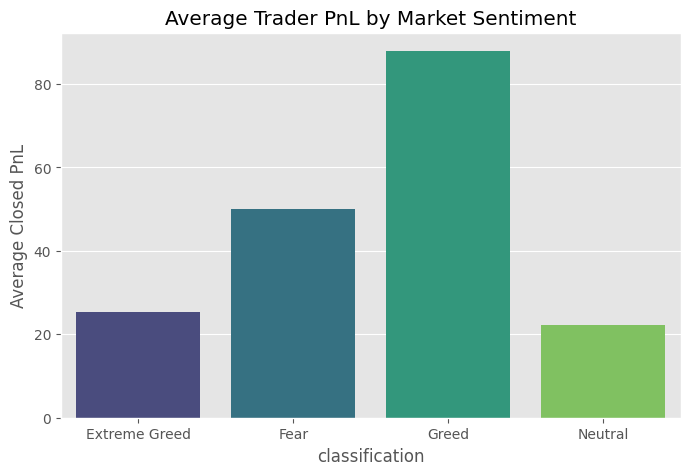

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=pnl_by_sentiment,
    palette='viridis'
)

plt.title("Average Trader PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

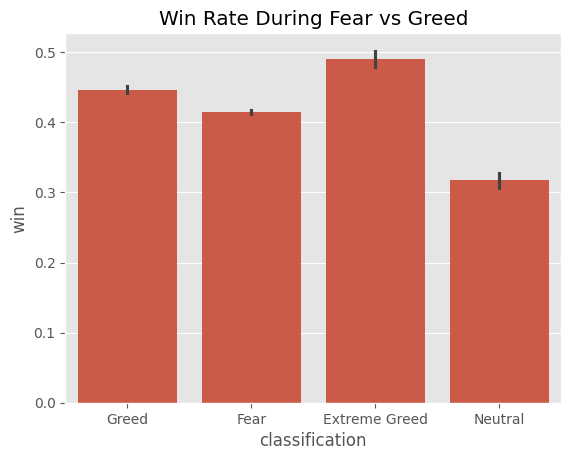

In [38]:

sns.barplot(x='classification', y='win', data=data)

plt.title("Win Rate During Fear vs Greed")

plt.show()

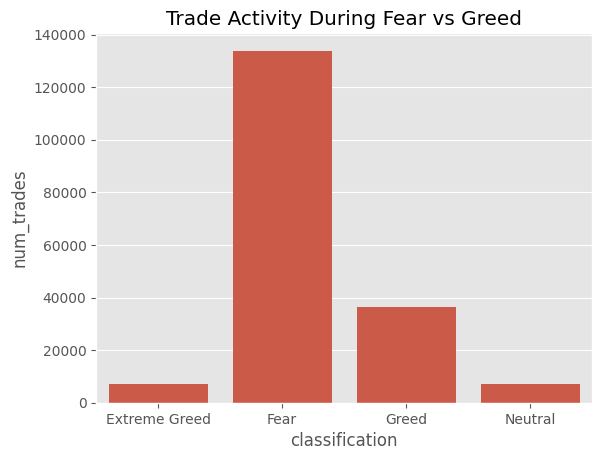

In [40]:
trades_by_sentiment = data.groupby('classification').size().reset_index(name='num_trades')

trades_by_sentiment
sns.barplot(x='classification', y='num_trades', data=trades_by_sentiment)

plt.title("Trade Activity During Fear vs Greed")

plt.show()